# Big Data project -> Steam Games Revies

### Proposal

I'd like to propose a possible project for the Big Data exam, I'd like to mix 2 kaggle datasets:
- https://www.kaggle.com/datasets/kieranpoc/steam-reviews
- https://www.kaggle.com/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics

The proposal will analyse all reviews (data retrieved from the first dataset) and join them with games and genres (which are taken, instead, from the second dataset) in order to calculate the average hours played for positive vs negative reviews, broken down by genre. If the proposal is not hard enough I'm open to possible complications.


### Datasets

Review dataset columns structure:

recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location

It will be reduced to:
recommendationid[0], appid[1], game[2], author_steamid[3], review[11], weighted_vote_score[17]

App dataset column structure:

appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at

reduced to:

appid[0], name[1], type[2]

Genre dataset column structure:

id, genre

### Performance benchmarks setup

In [37]:
import time
import psutil
import json
from datetime import datetime
from typing import Dict, Any, List
import matplotlib.pyplot as plt
import pandas as pd

class PerformanceMonitor:
    """Monitor and track Spark job performance metrics"""
    
    def __init__(self):
        self.metrics = []
        self.current_operation = None
        self.start_time = None
        self.start_memory = None
        
    def start(self, operation_name: str):
        """Start monitoring an operation"""
        self.current_operation = operation_name
        self.start_time = time.time()
        self.start_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
        print(f"\n{'='*80}")
        print(f"Starting: {operation_name}")
        print(f"{'='*80}")
        
    def end(self, spark_context=None, record_count: int = None, additional_metrics: Dict = None):
        """End monitoring and record metrics"""
        if not self.current_operation:
            return
            
        end_time = time.time()
        end_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
        duration = end_time - self.start_time
        memory_delta = end_memory - self.start_memory
        
        metric = {
            'operation': self.current_operation,
            'duration_seconds': duration,
            'start_memory_mb': self.start_memory,
            'end_memory_mb': end_memory,
            'memory_delta_mb': memory_delta,
            'timestamp': datetime.now().isoformat(),
            'record_count': record_count
        }
        
        # Add Spark-specific metrics if available
        if spark_context:
            try:
                status = spark_context.statusTracker()
                metric['active_jobs'] = len(status.getActiveJobIds())
                metric['active_stages'] = len(status.getActiveStageIds())
            except:
                pass
        
        # Add any additional custom metrics
        if additional_metrics:
            metric.update(additional_metrics)
        
        self.metrics.append(metric)
        
        print(f"Completed: {self.current_operation}")
        print(f"Duration: {duration:.2f}s")
        print(f"Memory Delta: {memory_delta:+.2f} MB")
        if record_count:
            print(f"Records Processed: {record_count:,}")
            print(f"Throughput: {record_count/duration:,.0f} records/sec")
        print(f"{'='*80}\n")
        
        self.current_operation = None
        
    def get_summary(self) -> pd.DataFrame:
        """Get summary of all metrics as DataFrame"""
        return pd.DataFrame(self.metrics)
    
    def plot_performance(self):
        """Create performance visualization"""
        if not self.metrics:
            print("No metrics to plot")
            return
            
        df = pd.DataFrame(self.metrics)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Spark Performance Metrics', fontsize=16, fontweight='bold')
        
        # Execution time comparison
        axes[0, 0].barh(df['operation'], df['duration_seconds'], color='steelblue')
        axes[0, 0].set_xlabel('Duration (seconds)')
        axes[0, 0].set_title('Execution Time by Operation')
        axes[0, 0].grid(axis='x', alpha=0.3)
        
        # Memory usage
        axes[0, 1].barh(df['operation'], df['memory_delta_mb'], color='coral')
        axes[0, 1].set_xlabel('Memory Delta (MB)')
        axes[0, 1].set_title('Memory Impact by Operation')
        axes[0, 1].grid(axis='x', alpha=0.3)
        
        # Records processed (if available)
        df_with_counts = df[df['record_count'].notna()]
        if not df_with_counts.empty:
            axes[1, 0].barh(df_with_counts['operation'], df_with_counts['record_count'], color='mediumseagreen')
            axes[1, 0].set_xlabel('Records Processed')
            axes[1, 0].set_title('Data Volume by Operation')
            axes[1, 0].grid(axis='x', alpha=0.3)
        
        # Throughput (records/sec)
        df_with_counts['throughput'] = df_with_counts['record_count'] / df_with_counts['duration_seconds']
        if not df_with_counts.empty:
            axes[1, 1].barh(df_with_counts['operation'], df_with_counts['throughput'], color='mediumpurple')
            axes[1, 1].set_xlabel('Throughput (records/sec)')
            axes[1, 1].set_title('Processing Throughput')
            axes[1, 1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def save_report(self, filename='performance_report.json'):
        """Save metrics to JSON file"""
        with open(filename, 'w') as f:
            json.dump(self.metrics, f, indent=2)
        print(f"Performance report saved to {filename}")

# Initialize performance monitor
perf = PerformanceMonitor()
print("Performance monitoring initialized!")

Performance monitoring initialized!


### Dataset loading

In [38]:
from pyspark.sql import SparkSession

In [39]:
perf.start("Spark Session Initialization")

spark = SparkSession.builder \
    .master("local[4]") \
    .appName("Local Spark Opt with Benchmarks") \
    .config('spark.ui.port', '4040') \
    .config('spark.sql.shuffle.partitions', '200') \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.default.parallelism", "8") \
    .getOrCreate()
sc = spark.sparkContext

sc.setLogLevel("WARN")

perf.end(sc)


Starting: Spark Session Initialization
Completed: Spark Session Initialization
Duration: 0.01s
Memory Delta: +0.00 MB



In [40]:
from typing import Optional, Tuple
from pyspark.sql import Row

class SteamParser:
    @staticmethod
    def parse_review_line(row) -> Optional[Tuple[int, bool, float, float, float]]:
        try:
            parts = list(row)
            
            appid = int(parts[1].strip())
            playtime_forever = float(parts[6].strip()) if parts[6].strip() else 0.0
            playtime_at_review = float(parts[8].strip()) if parts[8].strip() else 0.0
            voted_up_str = parts[14].strip().lower()
            voted_up = True if voted_up_str in ('true', '1', 'yes') else False
            weight_vote_score = float(parts[17].strip())
            # Filter invalid data
            if playtime_at_review < 0:
                return None
            return (appid, voted_up, playtime_forever, playtime_at_review, weight_vote_score)
        except:
            return None

    @staticmethod
    def parse_genre_line(row) -> Optional[Tuple[int, str]]:
        try:
            parts = list(row)
            
            genre_id = int(parts[0].strip())
            genre_name = parts[1].strip()
            
            if not genre_name:
                return None
            return (genre_id, genre_name)
        except:
            return None

    @staticmethod
    def parse_app_genre_line(row) -> Optional[Tuple[int, int]]:
        try:
            parts = list(row)

            appid = int(parts[0].strip())
            genre_id = int(parts[1].strip())
            return (appid, genre_id)
        except:
            return None

In [41]:
reviewFilePath = "datasets/small_reviews.csv"
genreFilePath = "datasets/genres.csv"
genreByAppFilePath = "datasets/application_genres_standardized.csv"

df_reviews = spark.read.csv(reviewFilePath, header=True, quote='\"', escape='\"', multiLine=True)
rddReviews = df_reviews.rdd.map(SteamParser.parse_review_line).filter(lambda x: x is not None)

# 2. Load Genres (Eager for Broadcast)
df_genres = spark.read.csv(genreFilePath, header=True, quote='\"', escape='\"', multiLine=True)
rddGenres = df_genres.rdd.map(SteamParser.parse_genre_line).filter(lambda x: x is not None) \
                .partitionBy(8) \
                .cache()

# 3. Load App Genres (Eager for Broadcast)
df_app_genres = spark.read.csv(genreByAppFilePath, header=True, quote='\"', escape='\"', multiLine=True)
rddGenresByApp = df_app_genres.rdd.map(SteamParser.parse_app_genre_line).filter(lambda x: x is not None)

In [42]:
perf.start("Optimization: Setup Broadcast Variables")

# 1. Collect Genres into a dictionary {genre_id: genre_name}
genre_lookup = rddGenres.collectAsMap()
# 2. Collect App-Genres into a dictionary {appid: [genre_id_1, genre_id_2, ...]}
app_genre_lookup = rddGenresByApp \
    .map(lambda x: (x[0], x[1])) \
    .groupByKey() \
    .mapValues(list) \
    .collectAsMap()

# 3. Broadcast to cluster\n",
bc_genre_lookup = sc.broadcast(genre_lookup)
bc_app_genre_lookup = sc.broadcast(app_genre_lookup)

perf.end(sc, len(app_genre_lookup), {'type': 'broadcast_creation'})


Starting: Optimization: Setup Broadcast Variables
Completed: Optimization: Setup Broadcast Variables
Duration: 3.49s
Memory Delta: +4.23 MB
Records Processed: 207,937
Throughput: 59,496 records/sec



### Execution

In [43]:
num_partitions = 8

In [44]:
def map_review_to_stats(row):
    # (appid, voted_up, playtime_forever, playtime_at_review, weight_vote_score)
    appid = row[0]
    voted_up = row[1]
    playtime = row[3]
    weight = row[4]

    # .value gives access to the dictionary on the worker node
    app_genres = bc_app_genre_lookup.value.get(appid)

    results = []
    if app_genres:
        sentiment = "Positive" if voted_up else "Negative"
        weighted_hours = playtime * weight

        for genre_id in app_genres:
            genre_name = bc_genre_lookup.value.get(genre_id)
            if genre_name:
                results.append(((genre_name, sentiment), (weighted_hours, weight, 1)))
    return results

perf.start("Optimized Pipeline: Map-Side Join + Aggregation")

final_results = rddReviews \
    .flatMap(map_review_to_stats) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2])) \
    .map(lambda x: (
        x[0][0],                                    # Genre\n",
        x[0][1],                                    # Sentiment\n",
        x[1][0] / x[1][1] if x[1][1] > 0 else 0.0,  # Avg Weighted Hours\n",
        x[1][2]                                     # Review Count\n",
    )) \
    .sortBy(lambda x: (x[0], x[1])) \
    .collect()

perf.end(sc, len(final_results), {'type': 'optimized_execution'})


Starting: Optimized Pipeline: Map-Side Join + Aggregation
Completed: Optimized Pipeline: Map-Side Join + Aggregation
Duration: 1.67s
Memory Delta: +0.00 MB
Records Processed: 54
Throughput: 32 records/sec



In [45]:
print("\n" + "="*80)
print("AVERAGE HOURS PLAYED: POSITIVE VS NEGATIVE REVIEWS BY GENRE")
print("="*80)
print(f"{'Genre':<30} {'Sentiment':<12} {'Avg Hours':<15} {'Review Count':<15}")
print("-"*80)

for genre, sentiment, avg_hours, count in final_results:
    print(f"{genre:<30} {sentiment:<12} {avg_hours:<15.2f} {count:<15,}")

print("="*80)


AVERAGE HOURS PLAYED: POSITIVE VS NEGATIVE REVIEWS BY GENRE
Genre                          Sentiment    Avg Hours       Review Count   
--------------------------------------------------------------------------------
Action                         Negative     8634.85         2,927          
Action                         Positive     8827.51         15,688         
Adventure                      Negative     6482.22         1,810          
Adventure                      Positive     5568.65         9,486          
Animation & Modeling           Negative     661.21          13             
Animation & Modeling           Positive     8615.48         216            
Audio Production               Negative     460.00          2              
Audio Production               Positive     6862.46         17             
Casual                         Negative     8286.78         531            
Casual                         Positive     4908.03         3,641          
Design & Illustration 

In [46]:
perf.start("Generate Genre Comparison Analysis")

genre_comparison = {}
for genre, sentiment, avg_hours, count in final_results:
    if genre not in genre_comparison:
        genre_comparison[genre] = {}
    genre_comparison[genre][sentiment] = {"avg_hours": avg_hours, "count": count}

print("\n" + "="*106)
print("GENRE COMPARISON SUMMARY")
print("="*106)
print(f"{'Genre':<30} {'Pos Hrs':<12} {'Neg Hrs':<12} {'Diff':<15} {'Total Reviews':<15}")
print("-"*106)

comparison_list = []
for genre, data in genre_comparison.items():
    pos = data.get("Positive", {}).get("avg_hours", 0)
    neg = data.get("Negative", {}).get("avg_hours", 0)
    total = data.get("Positive", {}).get("count", 0) + data.get("Negative", {}).get("count", 0)
    comparison_list.append((genre, pos, neg, pos - neg, total))

comparison_list.sort(key=lambda x: x[3], reverse=True)

perf.end(sc, len(comparison_list), {'analysis_type': 'genre_comparison'})

for genre, pos, neg, diff, total in comparison_list:
    sentiment = 'Positive' if diff > 0 else 'Negative' if diff < 0 else 'Neutral'
    print(f"{genre:<30} {pos:<12.2f} {neg:<12.2f} {diff:<+15.2f} {total:<15,} {sentiment: <20}")
print("="*106)


Starting: Generate Genre Comparison Analysis

GENRE COMPARISON SUMMARY
Genre                          Pos Hrs      Neg Hrs      Diff            Total Reviews  
----------------------------------------------------------------------------------------------------------
Completed: Generate Genre Comparison Analysis
Duration: 0.00s
Memory Delta: +0.00 MB
Records Processed: 29
Throughput: 42,619 records/sec

Video Production               19623.03     981.61       +18641.41       42              Positive            
Animation & Modeling           8615.48      661.21       +7954.27        229             Positive            
Audio Production               6862.46      460.00       +6402.46        19              Positive            
Design & Illustration          5857.42      486.97       +5370.45        227             Positive            
Racing                         5948.11      1645.77      +4302.34        757             Positive            
Utilities                      4948.01     

In [47]:
perf.start("Sentiment by Playtime Bracket Analysis")

def categorize_playtime(hours):
    if hours < 2:
        return "000-0h (Refund Window)"
    elif hours < 10:
        return "002-10h (Early Game)"
    elif hours < 50:
        return "010-50h (Mid Game)"
    elif hours < 200:
        return "050-200h (Committed)"
    else:
        return "200+h (Hardcore)"

bracket_results = rddReviews.map(
    lambda x: (categorize_playtime(x[2]), (1 if x[1] else 0, 1))
).reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1])
).map(
    lambda x: (x[0], x[1][0] / x[1][1] * 100, x[1][1])  # (bracket, % positive, count)
).sortBy(lambda x: x[0]).collect()

perf.end(sc, len(bracket_results), {'analysis_type': 'playtime_brackets'})


Starting: Sentiment by Playtime Bracket Analysis
Completed: Sentiment by Playtime Bracket Analysis
Duration: 1.62s
Memory Delta: +0.00 MB
Records Processed: 5
Throughput: 3 records/sec



In [48]:
print("\n" + "="*80)
print("SENTIMENT BY PLAYTIME BRACKET")
print("="*80)
print(f"{'Playtime Bracket':<30} {'% Positive':<15} {'Review Count':<15}")
print("-"*80)
for bracket, pct_positive, count in bracket_results:
    print(f"{bracket:<30} {pct_positive:<15.2f} {count:<15,}")
print("="*80)


SENTIMENT BY PLAYTIME BRACKET
Playtime Bracket               % Positive      Review Count   
--------------------------------------------------------------------------------
000-0h (Refund Window)         72.07           444            
002-10h (Early Game)           46.46           198            
010-50h (Mid Game)             56.43           1,097          
050-200h (Committed)           71.74           2,042          
200+h (Hardcore)               88.07           25,032         


### Performance banchmark results

In [49]:
# Display performance summary
print("\n" + "="*100)
print("PERFORMANCE SUMMARY")
print("="*100)

summary_df = perf.get_summary()
print(summary_df[['operation', 'duration_seconds', 'memory_delta_mb', 'record_count']].to_string(index=False))

print("\n" + "="*100)
print("AGGREGATE STATISTICS")
print("="*100)
print(f"Total Operations: {len(summary_df)}")
print(f"Total Execution Time: {summary_df['duration_seconds'].sum():.2f} seconds")
print(f"Average Operation Time: {summary_df['duration_seconds'].mean():.2f} seconds")
print(f"Total Memory Delta: {summary_df['memory_delta_mb'].sum():.2f} MB")
print(f"Total Records Processed: {summary_df['record_count'].sum():,.0f}")
print("="*100)


PERFORMANCE SUMMARY
                                      operation  duration_seconds  memory_delta_mb  record_count
                   Spark Session Initialization          0.012966         0.000000           NaN
        Optimization: Setup Broadcast Variables          3.494960         4.226562      207937.0
Optimized Pipeline: Map-Side Join + Aggregation          1.668934         0.000000          54.0
             Generate Genre Comparison Analysis          0.000680         0.000000          29.0
         Sentiment by Playtime Bracket Analysis          1.617704         0.000000           5.0

AGGREGATE STATISTICS
Total Operations: 5
Total Execution Time: 6.80 seconds
Average Operation Time: 1.36 seconds
Total Memory Delta: 4.23 MB
Total Records Processed: 208,025


/tmp/ipykernel_3389/2156691594.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_counts['throughput'] = df_with_counts['record_count'] / df_with_counts['duration_seconds']


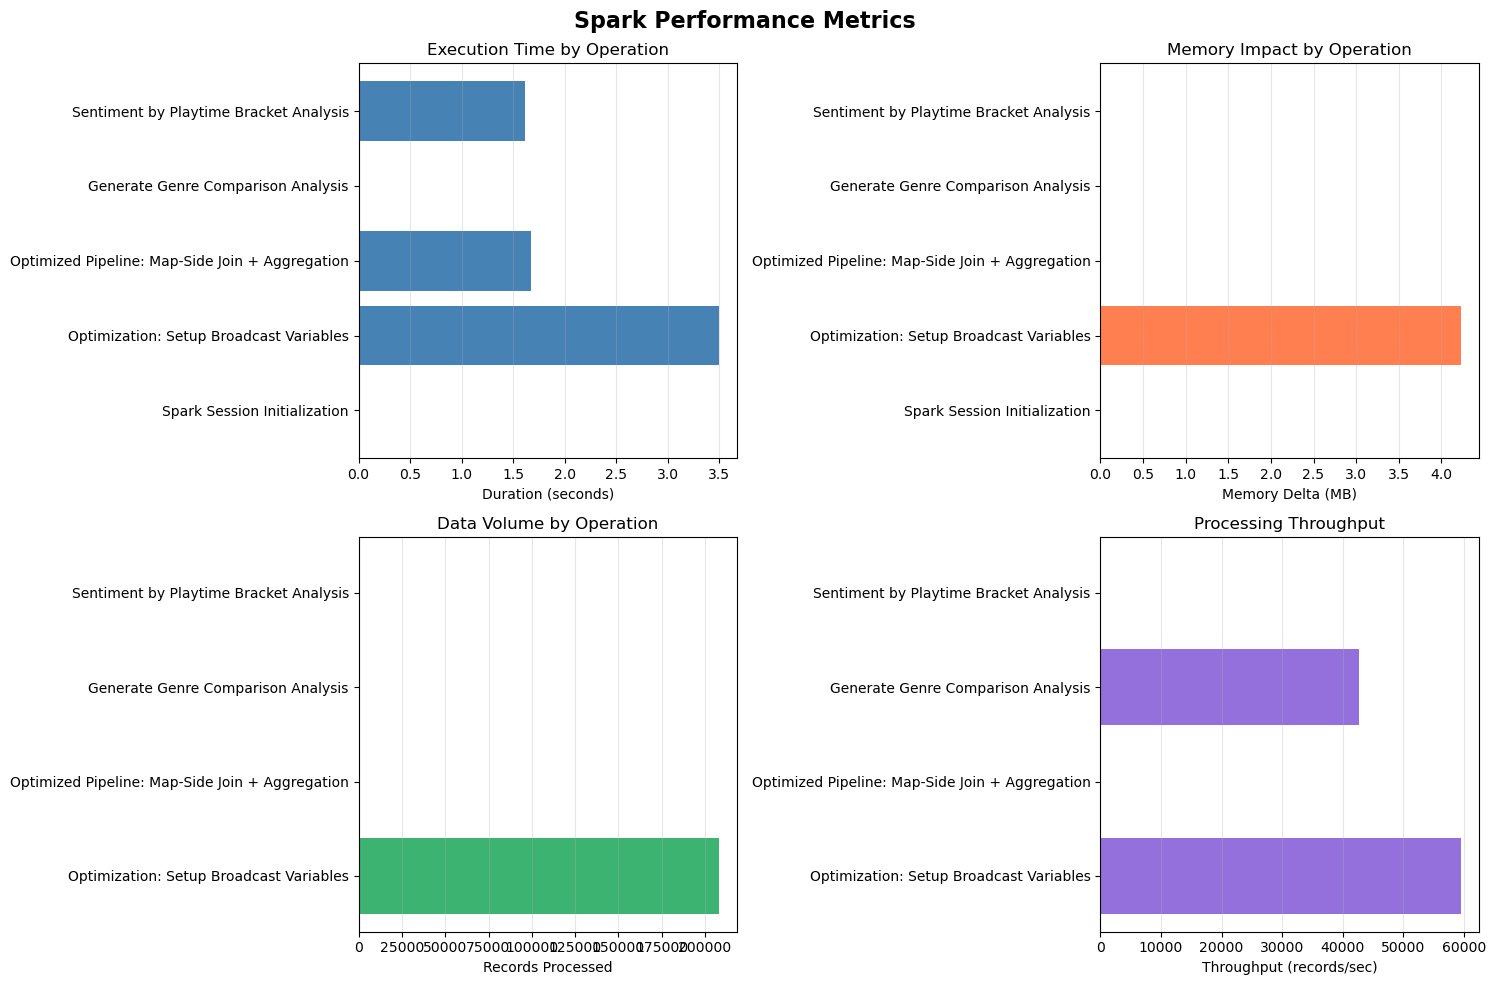

In [50]:
perf.plot_performance()

### Performance Optimization Comparison

In [51]:
# Test different partition counts
print("\n" + "="*80)
print("PARTITION COUNT OPTIMIZATION TEST")
print("="*80)

partition_counts = [4, 8, 16, 32]
partition_results = []

for num_partitions in partition_counts:
    print(f"\nTesting with {num_partitions} partitions...")
    
    start_time = time.time()
    
    # Repartition and perform a simple aggregation
    test_rdd = reviews_kv.repartition(num_partitions)
    result = test_rdd.mapValues(lambda x: 1).reduceByKey(lambda a, b: a + b).count()
    
    duration = time.time() - start_time
    partition_results.append((num_partitions, duration))
    
    print(f"Duration: {duration:.2f}s")

print("\n" + "="*80)
print(f"{'Partitions':<15} {'Duration (s)':<15} {'Speedup':<15}")
print("-"*80)
baseline = partition_results[0][1]
for parts, dur in partition_results:
    speedup = baseline / dur
    print(f"{parts:<15} {dur:<15.2f} {speedup:<15.2f}x")
print("="*80)


PARTITION COUNT OPTIMIZATION TEST

Testing with 4 partitions...


NameError: name 'reviews_kv' is not defined

In [ ]:
# Compare with and without caching
print("\n" + "="*80)
print("CACHING IMPACT TEST")
print("="*80)

# Without cache
print("\nRunning WITHOUT cache...")
test_rdd_no_cache = reviews.map(lambda x: (x[0], x[3]))

start_time = time.time()
count1 = test_rdd_no_cache.count()
count2 = test_rdd_no_cache.count()  # Second access
time_no_cache = time.time() - start_time

print(f"Time without cache (2 operations): {time_no_cache:.2f}s")

# With cache
print("\nRunning WITH cache...")
test_rdd_cache = rddReviews.map(lambda x: (x[0], x[3])).cache()

start_time = time.time()
count1 = test_rdd_cache.count()
count2 = test_rdd_cache.count()  # Second access
time_cache = time.time() - start_time

print(f"Time with cache (2 operations): {time_cache:.2f}s")
print(f"\nSpeedup from caching: {time_no_cache/time_cache:.2f}x")
print("="*80)

### Spark internal metrics

In [ ]:
# Get Spark execution metrics
print("\n" + "="*80)
print("SPARK EXECUTION METRICS")
print("="*80)

status = sc.statusTracker()

# print(f"Active Jobs: {len(status.getActiveJobIds())}")
print(f"Active Stages: {len(status.getActiveStageIds())}")
print(f"Default Parallelism: {sc.defaultParallelism}")

# Application metrics
print(f"\nApplication ID: {sc.applicationId}")
print(f"Spark Version: {sc.version}")
print(f"Master: {sc.master}")

print("\nAccess Spark UI for detailed metrics at: http://localhost:4040")
print("="*80)

### Save performane report

In [ ]:
# Save detailed performance report
perf.save_report('performance_report.json')

# Also save as CSV for easy analysis
summary_df = perf.get_summary()
summary_df.to_csv('performance_metrics.csv', index=False)
print("Performance metrics saved to performance_metrics.csv")

# Create a summary report
with open('performance_summary.txt', 'w') as f:
    f.write("SPARK PERFORMANCE BENCHMARK SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    f.write("Configuration:\n")
    f.write(f"  Master: {sc.master}\n")
    f.write(f"  Default Parallelism: {sc.defaultParallelism}\n")
    f.write(f"  Spark Version: {sc.version}\n\n")
    
    f.write("Overall Statistics:\n")
    f.write(f"  Total Operations: {len(summary_df)}\n")
    f.write(f"  Total Execution Time: {summary_df['duration_seconds'].sum():.2f}s\n")
    f.write(f"  Average Operation Time: {summary_df['duration_seconds'].mean():.2f}s\n")
    f.write(f"  Total Records Processed: {summary_df['record_count'].sum():,.0f}\n")
    f.write(f"  Total Memory Delta: {summary_df['memory_delta_mb'].sum():.2f} MB\n\n")
    
    f.write("Top 5 Slowest Operations:\n")
    slowest = summary_df.nlargest(5, 'duration_seconds')[['operation', 'duration_seconds']]
    f.write(slowest.to_string(index=False) + "\n\n")
    
    f.write("Top 5 Memory Intensive Operations:\n")
    memory_intensive = summary_df.nlargest(5, 'memory_delta_mb')[['operation', 'memory_delta_mb']]
    f.write(memory_intensive.to_string(index=False) + "\n")

print("Performance summary saved to performance_summary.txt")
print("\nAll benchmark results saved successfully!")